In [18]:
# ==============================================================================
# DATA CLEANING & STANDARDIZATION PIPELINE
# Project: An Explainable Machine Learning-Based Crop Yield Prediction and
#          Intelligent Decision Support System for Smart Agriculture.
# ==============================================================================

import pandas as pd
import numpy as np
import os
import io

# ------------------------------------------------------------------------------
# Configuration & File Paths
# ------------------------------------------------------------------------------
# Using the verbatim file names provided. Ensure these are uploaded to the Colab
# working directory (usually '/content/').
FILE_PATHS = {
    "Crop": "/content/District-wise, season-wise crop production statistics from 1997.csv",
    "Climate": "/content/Monthly mean maximum & minimum temperature and total rainfall based upon 1901-2000 data.csv",
    "Soil": "/content/soil_analysis_data.csv",
    "Fertilizer": "/content/State_UTs-wise Total Fertilizer Consumption from 2019-20 to 2021-22.csv",
    "Pesticide": "/content/Pesticide Consumption Data.csv"
}

CLEAN_PATHS = {
    "Crop": "Crop_Production_Clean.csv",
    "Rainfall": "Rainfall_Clean.csv",
    "Temperature": "Temperature_Clean.csv",
    "Soil": "Soil_Clean.csv",
    "Fertilizer": "Fertilizer_Clean.csv",
    "Pesticide": "Pesticide_Clean.csv"
}

# Tracking dictionaries for the final report
report_data = {
    "Before": {},
    "After": {},
    "Issues": {},
    "Standardizations": {}
}

# ------------------------------------------------------------------------------
# Step 1: Load Every Dataset
# ------------------------------------------------------------------------------
print("--- STEP 1: LOADING DATASETS ---")
datasets = {}

for name, path in FILE_PATHS.items():
    if os.path.exists(path):
        try:
            df = pd.read_csv(path)

            if name == "Climate":
                climate_df = df.copy()

                # Identify common identifier columns (assuming these are always present)
                common_id_cols_keywords = ['station name', 'month', 'period', 'no. of years']
                common_id_cols = [c for c in climate_df.columns if any(kw in c.lower() for kw in common_id_cols_keywords)]

                # Identify rainfall value column dynamically
                rainfall_value_col = next((c for c in climate_df.columns if 'total rainfall' in c.lower() or ('rainfall' in c.lower() and 'temp' not in c.lower())), None)

                # Identify temperature value columns dynamically, using 'and' for more robust matching
                temp_max_value_col = next((c for c in climate_df.columns if 'max' in c.lower() and 'temp' in c.lower()), None)
                temp_min_value_col = next((c for c in climate_df.columns if 'min' in c.lower() and 'temp' in c.lower()), None)

                # Construct Rainfall DataFrame
                if rainfall_value_col:
                    df_rainfall = climate_df[common_id_cols + [rainfall_value_col]].copy()
                    datasets["Rainfall"] = df_rainfall
                    report_data["Before"]["Rainfall"] = df_rainfall.shape[0]
                    print(f"\n✅ Successfully loaded and split: Rainfall")
                    print(f"   Shape: {df_rainfall.shape[0]} Rows × {df_rainfall.shape[1]} Columns")
                    print(f"   Memory Usage: {df_rainfall.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
                    print("   First 5 Rows:")
                    display(df_rainfall.head())
                else:
                    print(f"❌ Could not find a 'rainfall' column in Climate data. Skipping Rainfall dataset split.")
                    datasets["Rainfall"] = pd.DataFrame() # Add empty dataframe to prevent KeyError later

                # Construct Temperature DataFrame
                if temp_max_value_col and temp_min_value_col:
                    df_temperature = climate_df[common_id_cols + [temp_max_value_col, temp_min_value_col]].copy()
                    datasets["Temperature"] = df_temperature
                    report_data["Before"]["Temperature"] = df_temperature.shape[0]
                    print(f"\n✅ Successfully loaded and split: Temperature")
                    print(f"   Shape: {df_temperature.shape[0]} Rows × {df_temperature.shape[1]} Columns")
                    print(f"   Memory Usage: {df_temperature.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
                    print("   First 5 Rows:")
                    display(df_temperature.head())
                else:
                    print(f"❌ Could not find 'max' and 'temp' or 'min' and 'temp' columns in Climate data. Skipping Temperature dataset split.")
                    datasets["Temperature"] = pd.DataFrame() # Add empty dataframe to prevent KeyError later

            else:
                datasets[name] = df
                report_data["Before"][name] = df.shape[0]

                print(f"\n✅ Successfully loaded: {name}")
                print(f"   Shape: {df.shape[0]} Rows × {df.shape[1]} Columns")
                print(f"   Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
                print("   First 5 Rows:")
                display(df.head())
        except Exception as e:
            print(f"❌ Error loading {name}: {e}")
    else:
        print(f"⚠️ File not found: {path}. Please ensure it is uploaded.")

# ------------------------------------------------------------------------------
# Step 2: Data Quality Assessment (Functions)
# ------------------------------------------------------------------------------
def assess_data_quality(df, name):
    print(f"\n--- Assessing Data Quality: {name} ---")

    # 1. Missing Values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': missing_pct})
    missing_df = missing_df[missing_df['Missing Values'] > 0]

    if not missing_df.empty:
        print("\nMissing Values Summary:")
        display(missing_df)
    else:
        print("\nNo Missing Values detected.")

    # 2. Duplicate Records
    duplicates = df.duplicated().sum()
    print(f"\nExact Duplicate Rows: {duplicates}")

    # 3. Invalid Values (Domain Specific)
    invalid_issues = []
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    string_cols = df.select_dtypes(include=['object']).columns

    # Check for negative values in specific domain metrics
    for col in numeric_cols:
        col_lower = col.lower()
        if any(keyword in col_lower for keyword in ['production', 'area', 'yield', 'rainfall', 'consumption']):
            negatives = (df[col] < 0).sum()
            if negatives > 0:
                invalid_issues.append(f"{col} has {negatives} negative values.")
        if 'ph' in col_lower:
            invalid_ph = ((df[col] < 0) | (df[col] > 14)).sum()
            if invalid_ph > 0:
                invalid_issues.append(f"{col} has {invalid_ph} invalid pH values (outside 0-14).")

    # Check for empty strings or purely whitespace
    for col in string_cols:
        empty_strings = df[col].astype(str).str.strip().eq('').sum()
        if empty_strings > 0:
            invalid_issues.append(f"{col} has {empty_strings} empty or whitespace-only strings.")

    if invalid_issues:
        print("\nInvalid Values Detected:")
        for issue in invalid_issues:
            print(f" - {issue}")
    else:
        print("\nNo obvious invalid domain values detected.")

    report_data["Issues"][name] = invalid_issues
    return duplicates

# Run assessment
for name, df in datasets.items():
    assess_data_quality(df, name)

# ------------------------------------------------------------------------------
# Step 3 & 4: Standardization and Cleaning
# ------------------------------------------------------------------------------
print("\n--- STEP 3 & 4: STANDARDIZATION & CLEANING ---")

def standardize_and_clean(df, name):
    print(f"Processing: {name}...")
    df_clean = df.copy()
    actions_taken = []

    # 1. Remove exact duplicates
    initial_rows = len(df_clean)
    df_clean.drop_duplicates(inplace=True)
    if initial_rows - len(df_clean) > 0:
        actions_taken.append(f"Dropped {initial_rows - len(df_clean)} duplicate rows.")

    # 2. Standardize Categorical Text
    string_cols = df_clean.select_dtypes(include=['object']).columns

    for col in string_cols:
        col_name = col.lower()

        # Standardize States
        if 'state' in col_name or 'ut' in col_name:
            df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
            df_clean[col] = df_clean[col].replace({'Tamilnadu': 'Tamil Nadu'})
            actions_taken.append(f"Standardized State names in column '{col}' to Title Case.")

        # Standardize Districts
        elif 'district' in col_name:
            df_clean[col] = df_clean[col].astype(str).str.strip().str.upper()
            df_clean[col] = df_clean[col].str.replace('[^A-Z0-9]', '', regex=True)
            actions_taken.append(f"Standardized District names in column '{col}' to UPPERCASE and removed special characters.")

        # Standardize Crops
        elif 'crop' in col_name:
            df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
            actions_taken.append(f"Standardized Crop names in column '{col}' to Title Case.")

        # Standardize Seasons
        elif 'season' in col_name:
            df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
            actions_taken.append(f"Standardized Season names in column '{col}' to Title Case.")

        # General whitespace cleanup for other text columns
        else:
            df_clean[col] = df_clean[col].astype(str).str.strip()

    # 3. Handle Invalid Numeric Values (Negatives in area/production)
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        col_lower = col.lower()
        if any(keyword in col_lower for keyword in ['production', 'area', 'rainfall', 'consumption']):
            # Convert negative anomalies to NaN for imputation
            neg_mask = df_clean[col] < 0
            if neg_mask.sum() > 0:
                df_clean.loc[neg_mask, col] = np.nan
                actions_taken.append(f"Replaced {neg_mask.sum()} negative values in '{col}' with NaN.")

        if 'ph' in col_lower:
            invalid_ph = (df_clean[col] < 0) | (df_clean[col] > 14)
            if invalid_ph.sum() > 0:
                df_clean.loc[invalid_ph, col] = np.nan
                actions_taken.append(f"Replaced {invalid_ph.sum()} invalid pH values in '{col}' with NaN.")

    # 4. Handle Missing Values
    for col in df_clean.columns:
        missing_count = df_clean[col].isnull().sum()
        if missing_count > 0:
            missing_pct = missing_count / len(df_clean)

            # If missing > 60%, log it but keep it (instructed to keep as much data as possible)
            if missing_pct > 0.60:
                actions_taken.append(f"Warning: Column '{col}' has {missing_pct:.1%} missing data. Left as NaN to avoid biased imputation.")

            # Numeric imputation (Median for skewed agriculture data)
            elif pd.api.types.is_numeric_dtype(df_clean[col]):
                median_val = df_clean[col].median()
                df_clean[col].fillna(median_val, inplace=True)
                actions_taken.append(f"Imputed {missing_count} missing values in '{col}' with median ({median_val:.2f}).")

            # Categorical imputation (Mode)
            else:
                mode_val = df_clean[col].mode()[0]
                df_clean[col].fillna(mode_val, inplace=True)
                actions_taken.append(f"Imputed {missing_count} missing values in '{col}' with mode ('{mode_val}').")

    report_data["Standardizations"][name] = actions_taken
    return df_clean

cleaned_datasets = {}
for name, df in datasets.items():
    if not df.empty: # Only process if dataframe is not empty
        cleaned_datasets[name] = standardize_and_clean(df, name)
        report_data["After"][name] = len(cleaned_datasets[name])
    else:
        print(f"Skipping cleaning for empty dataset: {name}")
        cleaned_datasets[name] = pd.DataFrame() # Ensure an empty dataframe is present in cleaned_datasets
        report_data["After"][name] = 0 # Update after count to 0 for empty datasets

# ------------------------------------------------------------------------------
# Step 5: Validation
# ------------------------------------------------------------------------------
print("\n--- STEP 5: VALIDATION (Before vs After) ---")

for name in datasets.keys():
    print(f"\nDataset: {name}")
    print(f"Rows Before: {report_data['Before'].get(name, 0)} | Rows After: {report_data['After'].get(name, 0)}")

    # Ensure dataframes exist before calculating missing and duplicates
    if name in datasets and not datasets[name].empty:
        missing_before = datasets[name].isnull().sum().sum()
        duplicates_before = datasets[name].duplicated().sum()
    else:
        missing_before = 0
        duplicates_before = 0

    if name in cleaned_datasets and not cleaned_datasets[name].empty:
        missing_after = cleaned_datasets[name].isnull().sum().sum()
        duplicates_after = cleaned_datasets[name].duplicated().sum()
    else:
        missing_after = 0
        duplicates_after = 0

    print(f"Total Missing Values: {missing_before} -> {missing_after}")
    print(f"Total Duplicates: {duplicates_before} -> {duplicates_after}")

# ------------------------------------------------------------------------------
# Step 6: Save Outputs
# ------------------------------------------------------------------------------
print("\n--- STEP 6: SAVING CLEANED DATASETS ---")

for name, df_clean in cleaned_datasets.items():
    if not df_clean.empty:
        out_path = CLEAN_PATHS[name]
        df_clean.to_csv(out_path, index=False)
        print(f"✅ Saved cleaned dataset to: {out_path}")
    else:
        print(f"Skipping saving for empty dataset: {name}")

# ------------------------------------------------------------------------------
# Step 7: Generate Professional Markdown Report
# ------------------------------------------------------------------------------
print("\n--- STEP 7: GENERATING REPORT ---")

report_content = f"""# Data Cleaning & Standardization Report\n**Project:** An Explainable Machine Learning-Based Crop Yield Prediction and Intelligent Decision Support System for Smart Agriculture.\n\n## Dataset Summary\n\n| Dataset Name | Rows Before | Rows After | Rows Dropped |\n|--------------|-------------|------------|--------------|\n"""

# Iterate over all possible dataset names, including the split ones
all_dataset_names = sorted(list(set(FILE_PATHS.keys()) | set(CLEAN_PATHS.keys()))) # Get all unique dataset names

for name in all_dataset_names:
    before = report_data['Before'].get(name, 0)
    after = report_data['After'].get(name, 0)
    dropped = before - after
    report_content += f"| {name} | {before} | {after} | {dropped} |\n"

report_content += "\n## Cleaning & Standardization Decisions\n"

for name in all_dataset_names:
    report_content += f"\n### {name}\n"
    if name in report_data["Issues"] and report_data["Issues"][name]:
        report_content += "**Initial Issues Detected:**\n"
        for issue in report_data["Issues"][name]:
            report_content += f"- {issue}\n"
    else:
        report_content += "**Initial Issues Detected:**\n- No specific issues detected or data not processed yet.\n"


    report_content += "\n**Transformations Applied:**\n"
    if name in report_data["Standardizations"] and report_data["Standardizations"][name]:
        for action in report_data["Standardizations"][name]:
            report_content += f"- {action}\n"
    else:
        report_content += "- No specific standardizations applied or data not processed yet.\n"


with open("Cleaning_Report.md", "w") as f:
    f.write(report_content)

print("✅ Generated Cleaning_Report.md successfully.")
print("\n🚀 PIPELINE EXECUTION COMPLETE. DATASETS ARE READY FOR INTEGRATION.")


--- STEP 1: LOADING DATASETS ---

✅ Successfully loaded: Crop
   Shape: 246091 Rows × 7 Columns
   Memory Usage: 59.38 MB
   First 5 Rows:


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0



✅ Successfully loaded and split: Rainfall
   Shape: 1332 Rows × 5 Columns
   Memory Usage: 0.24 MB
   First 5 Rows:


,Station Name,Month,Period,No. of Years,Mean Rainfall in mm
0,Abu,January,1901-2000,100,5.3
1,Abu,February,1901-2000,100,4.4
2,Abu,March,1901-2000,100,6.5
3,Abu,April,1901-2000,100,2.6
4,Abu,May,1901-2000,100,16.4



✅ Successfully loaded and split: Temperature
   Shape: 1332 Rows × 6 Columns
   Memory Usage: 0.25 MB
   First 5 Rows:


...


--- Assessing Data Quality: Crop ---

Missing Values Summary:


,Missing Values,Percentage (%)
Production,3730,1.515699



Exact Duplicate Rows: 0

No obvious invalid domain values detected.

--- Assessing Data Quality: Rainfall ---

No Missing Values detected.

Exact Duplicate Rows: 0

No obvious invalid domain values detected.

--- Assessing Data Quality: Temperature ---

No Missing Values detected.

Exact Duplicate Rows: 0

No obvious invalid domain values detected.

--- Assessing Data Quality: Soil ---

No Missing Values detected.

Exact Duplicate Rows: 0

Invalid Values Detected:
 - Phosphorus Content (kg/ha) has 867 invalid pH values (outside 0-14).

--- Assessing Data Quality: Fertilizer ---

No Missing Values detected.

Exact Duplicate Rows: 0

No obvious invalid domain values detected.

--- Assessing Data Quality: Pesticide ---

Missing Values Summary:


,Missing Values,Percentage (%)
2015-16,8,19.512195
2016-17,6,14.634146
2017-18,9,21.951220
2018-19,7,17.073171
2019-20,7,17.073171



Exact Duplicate Rows: 0

No obvious invalid domain values detected.

--- STEP 3 & 4: STANDARDIZATION & CLEANING ---
Processing: Crop...
Processing: Rainfall...
Processing: Temperature...
Processing: Soil...
Processing: Fertilizer...
Processing: Pesticide...

--- STEP 5: VALIDATION (Before vs After) ---

Dataset: Crop
Rows Before: 246091 | Rows After: 246091
Total Missing Values: 3730 -> 0
Total Duplicates: 0 -> 0

Dataset: Rainfall
Rows Before: 1332 | Rows After: 1332
Total Missing Values: 0 -> 0
Total Duplicates: 0 -> 0

Dataset: Temperature
Rows Before: 1332 | Rows After: 1332
Total Missing Values: 0 -> 0
Total Duplicates: 0 -> 0

Dataset: Soil
Rows Before: 1000 | Rows After: 1000
Total Missing Values: 0 -> 867
Total Duplicates: 0 -> 0

Dataset: Fertilizer
Rows Before: 42 | Rows After: 42
Total Missing Values: 0 -> 0
Total Duplicates: 0 -> 0

Dataset: Pesticide
Rows Before: 41 | Rows After: 41
Total Missing Values: 37 -> 0
Total Duplicates: 0 -> 0

--- STEP 6: SAVING CLEANED DATASET

--- LOADING CLEANED DATASETS ---
✅ Loaded Crop (246091 rows, 7 cols)
✅ Loaded Rainfall (1332 rows, 5 cols)
✅ Loaded Temperature (1332 rows, 6 cols)
✅ Loaded Soil (1000 rows, 7 cols)
✅ Loaded Fertilizer (42 rows, 4 cols)
✅ Loaded Pesticide (41 rows, 7 cols)

PRE-EDA CLEANING & IMPROVEMENTS

--- Cleaning Pesticide Dataset ---
✅ Pesticide dataset cleaned. 1 non-numeric values converted to NaN.

--- Processing Soil Dataset ---
Phosphorus column 'Phosphorus Content (kg/ha)' has 86.70% missing values.
Dropped Phosphorus Content column because missing values exceeded 80%.

PART 1: EXPLORATORY DATA ANALYSIS

--- Crop Dataset Overview ---
Shape: (246091, 7)
No missing values detected.

--- Rainfall Dataset Overview ---
Shape: (1332, 5)
No missing values detected.

--- Temperature Dataset Overview ---
Shape: (1332, 6)
No missing values detected.

--- Soil Dataset Overview ---
Shape: (1000, 6)
No missing values detected.

--- Fertilizer Dataset Overview ---
Shape: (42, 4)
No missing values detect

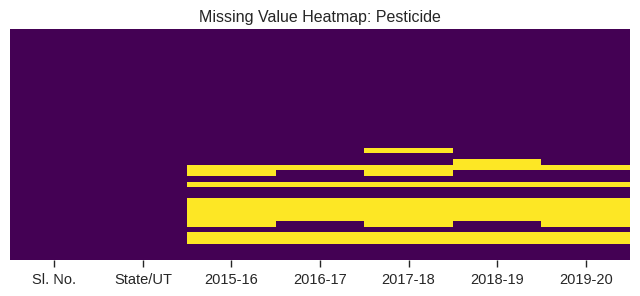


💡 INSIGHT:
• What it shows: Locations of missing values across Pesticide features.
• Observations: Highlights columns/rows with concentrated missingness.
• Why it matters: Guides advanced imputation strategies or feature dropping.

--------------------------------------------------

--- CROP DATASET ANALYSIS ---


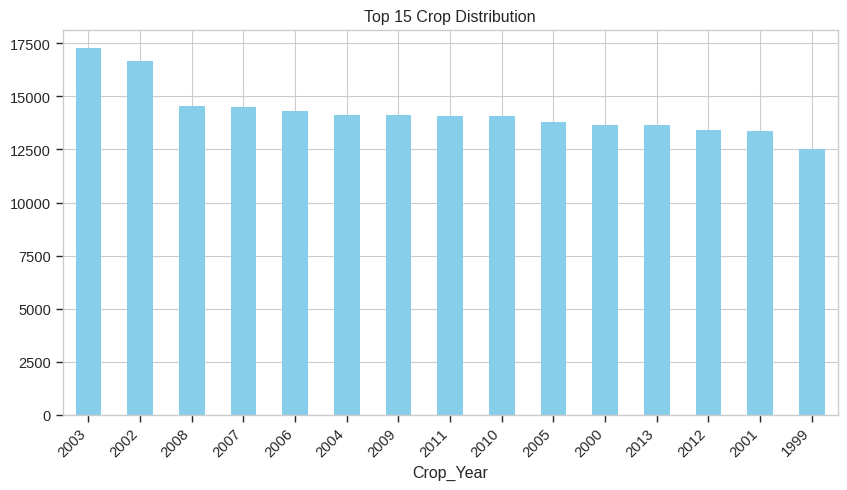


💡 INSIGHT:
• What it shows: Frequency of the top 15 cultivated crops.
• Observations: A few staple crops dominate the dataset.
• Why it matters: Models must account for this imbalance to prevent bias.

--------------------------------------------------


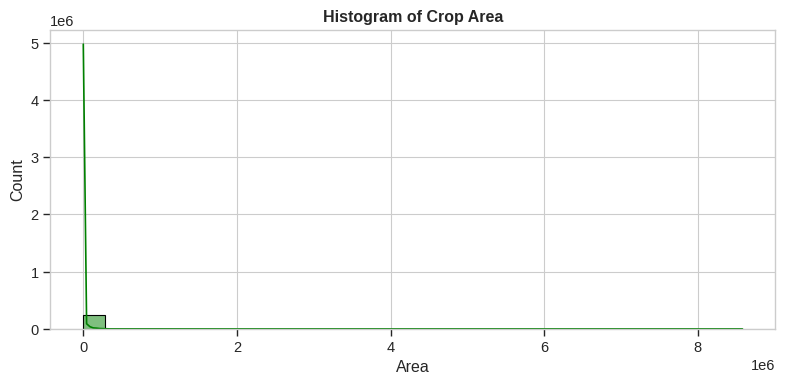

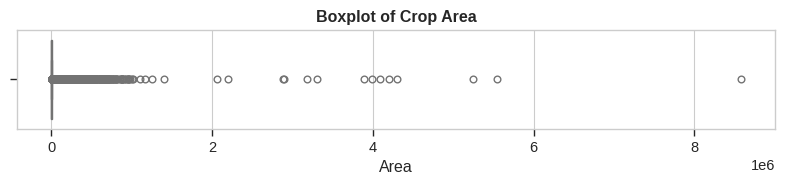

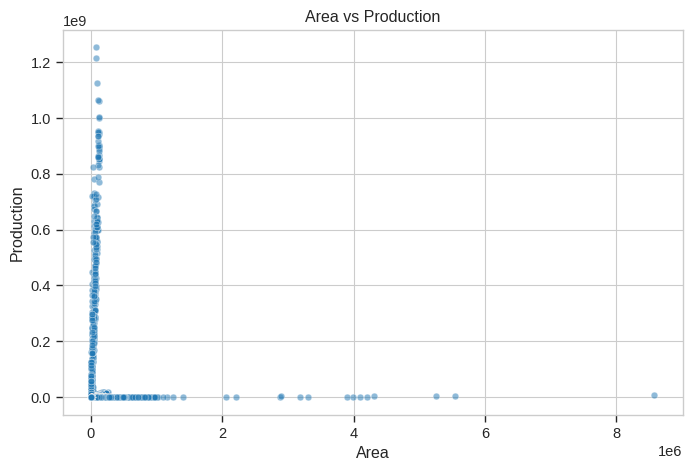


--- RAINFALL DATASET VALIDATION & ANALYSIS ---

Analyzing Rainfall Column: Mean Rainfall in mm
Mean: 126.10 | Median: 51.15 | Std Dev: 210.64
Identified 83 outliers in Mean Rainfall in mm.


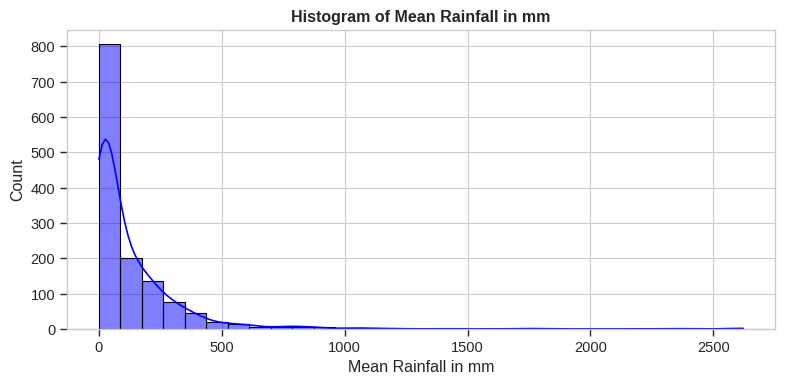

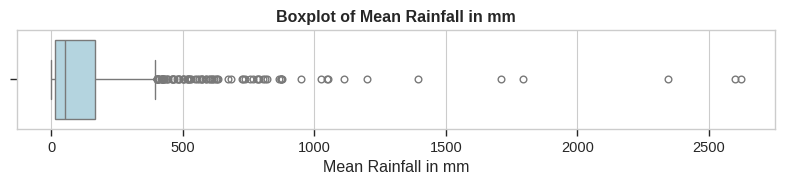


--- TEMPERATURE DATASET VALIDATION & ANALYSIS ---

Analyzing Temperature Column: Mean Temperature in degree C - Maximum
Mean: 29.90 | Median: 30.70 | Std Dev: 6.09


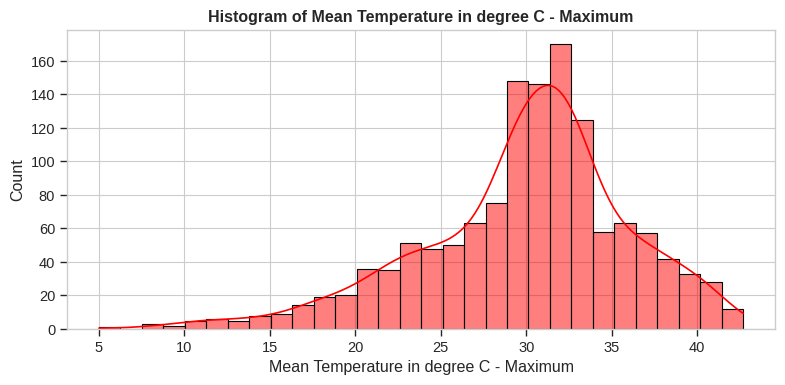

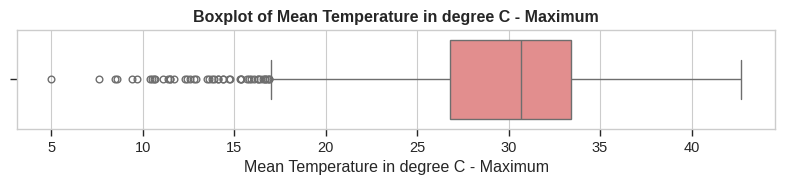


Analyzing Temperature Column: Mean Temperature  in degree C - Minimum
Mean: 18.82 | Median: 20.60 | Std Dev: 6.46


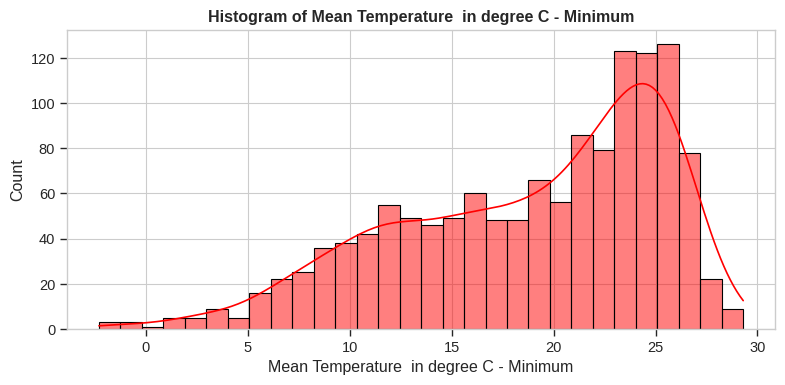

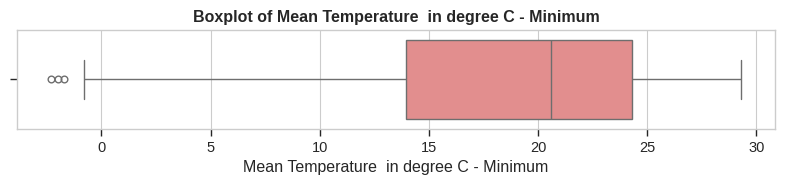


PART 2: FEATURE ENGINEERING
✅ Yield calculated safely.
✅ Created Log_Production.
✅ Created Farm_Size quartiles.
✅ Label Encoded columns: Season_Encoded, Crop_Encoded, State_Name_Encoded, District_Name_Encoded
✅ Rainfall: Engineered macro features.
✅ Temperature: Engineered Average & Range features.
✅ Soil: Engineered Soil_Fertility_Index using Nitrogen, Potassium.
⚠️ Fertilizer: Could not find suitable id_vars or yearly columns for melting.
✅ Pesticide: Converted Wide format to Long format.

ADDITIONAL EDA (Post-Feature Engineering)


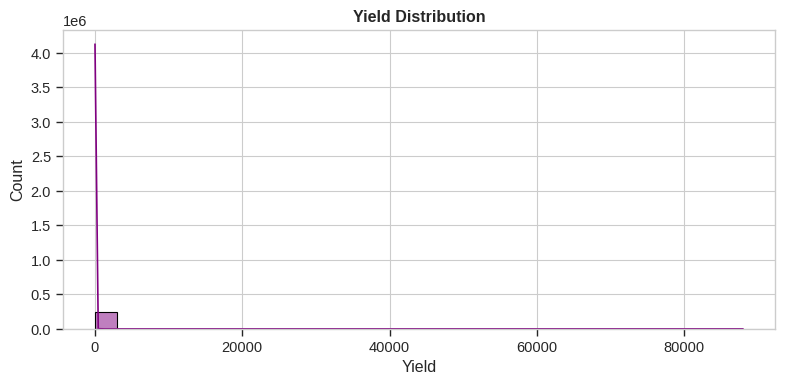


💡 INSIGHT:
• What it shows: The normalized distribution of crop yield (Production/Area).
• Observations: Provides a much more standardized target variable compared to sheer production.
• Why it matters: Yield modeling generalizes better across different farm sizes.

--------------------------------------------------


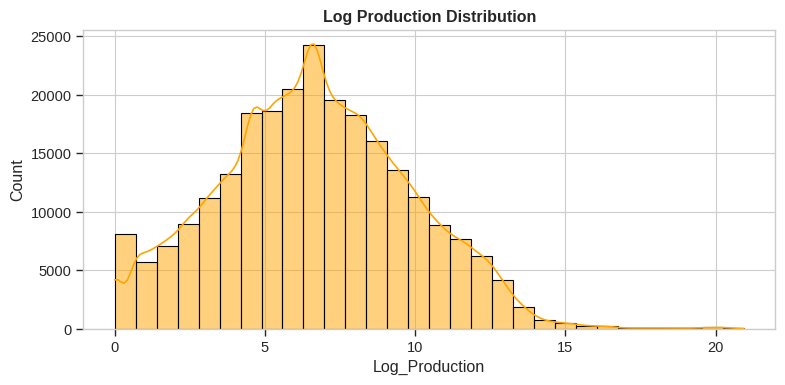


💡 INSIGHT:
• What it shows: Production values scaled logarithmically.
• Observations: Reduces extreme positive skewness evident in the raw production data.
• Why it matters: Improves linear model convergence and robustness to outliers.

--------------------------------------------------


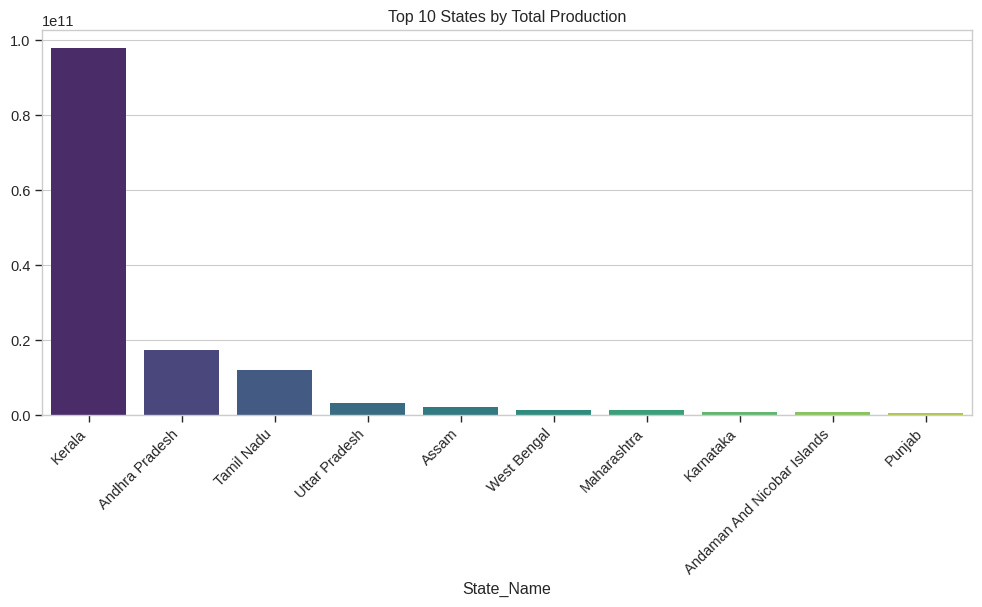


💡 INSIGHT:
• What it shows: Aggregate crop production across states.
• Observations: Clear regional disparities in total output.
• Why it matters: Confirms location as a critical implicit feature for weather and soil baseline.

--------------------------------------------------


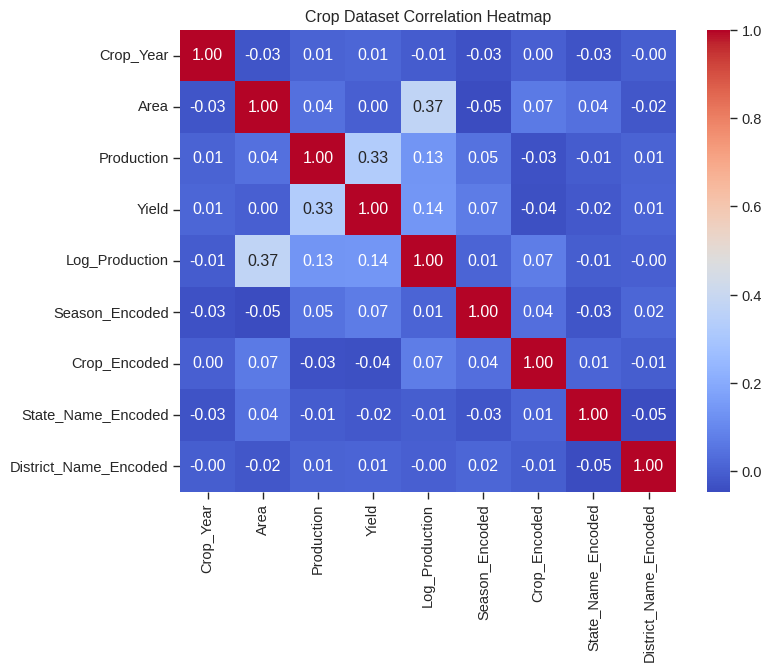


💡 INSIGHT:
• What it shows: Pearson correlation between numeric crop features.
• Observations: Highlights relationships like Area vs. Production vs. Log_Production.
• Why it matters: Ensures we are aware of collinear features before model training.

--------------------------------------------------

SAVING FEATURED DATASETS
💾 Overwritten / Saved: Crop_Featured.csv
💾 Overwritten / Saved: Rainfall_Featured.csv
💾 Overwritten / Saved: Temperature_Featured.csv
💾 Overwritten / Saved: Soil_Featured.csv
💾 Overwritten / Saved: Fertilizer_Featured.csv
💾 Overwritten / Saved: Pesticide_Featured.csv

DELIVERABLES SUMMARY
📝 Updated: EDA_Report.md
📝 Updated: Feature_Engineering_Report.md

--- FIRST 5 ROWS OF FEATURED DATASETS ---

Crop Dataset:


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,Yield,Log_Production,Farm_Size,Season_Encoded,Crop_Encoded,State_Name_Encoded,District_Name_Encoded
0,Andaman And Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896,7.601402,Medium,1,2,0,427
1,Andaman And Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif Pulses,2.0,1.0,0.500000,0.693147,Small,1,75,0,427
2,Andaman And Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059,5.774552,Medium,1,98,0,427
3,Andaman And Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045,6.464588,Medium,4,7,0,427
4,Andaman And Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167,5.111988,Medium,4,22,0,427



Rainfall Dataset:


,Station Name,Month,Period,No. of Years,Mean Rainfall in mm,Annual_Rainfall,Average_Rainfall,Rainy_Months_Count
0,Abu,January,1901-2000,100,5.3,5.3,5.3,1
1,Abu,February,1901-2000,100,4.4,4.4,4.4,1
2,Abu,March,1901-2000,100,6.5,6.5,6.5,1
3,Abu,April,1901-2000,100,2.6,2.6,2.6,1
4,Abu,May,1901-2000,100,16.4,16.4,16.4,1



Temperature Dataset:


...


Fertilizer Dataset:


,State/UT,Total - 2019-20,Total - 2020-21,Total - 2021-22
0,Andhra Pradesh,35.29,42.15,36.23
1,Telangana,31.89,38.84,35.38
2,Karnataka,37.90,45.10,45.61
3,Kerala,3.53,4.03,3.37
4,Tamil Nadu,20.83,23.75,24.32



Pesticide Dataset:


,State/UT,Year,Pesticide_Consumption
0,Andhra Pradesh,2015-16,2713.0
1,Bihar,2015-16,831.0
2,Chhattisgarh,2015-16,1625.0
3,Goa,2015-16,48.0
4,Gujarat,2015-16,1980.0



🚀 PIPELINE EXECUTION COMPLETE. DATASETS ARE READY FOR MERGING.


In [19]:
# ==============================================================================
# PHASE 2: EXPLORATORY DATA ANALYSIS & FEATURE ENGINEERING
# Project: An Explainable Machine Learning-Based Crop Yield Prediction and
#          Intelligent Decision Support System for Smart Agriculture.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

# Set plotting style for IEEE professional aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

# ==============================================================================
# CONFIGURATION & FILE PATHS
# ==============================================================================
CLEAN_FILES = {
    "Crop": "Crop_Production_Clean.csv",
    "Rainfall": "Rainfall_Clean.csv",
    "Temperature": "Temperature_Clean.csv",
    "Soil": "Soil_Clean.csv",
    "Fertilizer": "Fertilizer_Clean.csv",
    "Pesticide": "Pesticide_Clean.csv"
}

FEATURED_FILES = {
    "Crop": "Crop_Featured.csv",
    "Rainfall": "Rainfall_Featured.csv",
    "Temperature": "Temperature_Featured.csv",
    "Soil": "Soil_Featured.csv",
    "Fertilizer": "Fertilizer_Featured.csv",
    "Pesticide": "Pesticide_Featured.csv"
}

# Tracking metrics for the final report
tracking = {
    "viz_count": 0,
    "features_before": {},
    "features_after": {},
    "new_features": {}
}

# Load Data
print("--- LOADING CLEANED DATASETS ---")
data = {}
for name, file in CLEAN_FILES.items():
    if os.path.exists(file):
        data[name] = pd.read_csv(file)
        tracking["features_before"][name] = data[name].shape[1]
        print(f"✅ Loaded {name} ({data[name].shape[0]} rows, {data[name].shape[1]} cols)")
    else:
        print(f"⚠️ Warning: {file} not found. Creating a dummy dataframe for pipeline continuity.")
        data[name] = pd.DataFrame()

# ------------------------------------------------------------------------------
# PRE-EDA DATA CLEANING (PESTICIDE & SOIL IMPROVEMENTS)
# ------------------------------------------------------------------------------
print("\n" + "="*50)
print("PRE-EDA CLEANING & IMPROVEMENTS")
print("="*50)

# --- 4. PESTICIDE DATA CLEANING ---
df_pest = data.get("Pesticide", pd.DataFrame())
if not df_pest.empty:
    print("\n--- Cleaning Pesticide Dataset ---")
    non_numeric_vals = ['Organic State', 'Not Available', 'NA', '--', 'N/A']
    df_pest.replace(non_numeric_vals, np.nan, inplace=True)

    yearly_cols = [c for c in df_pest.columns if any(char.isdigit() for char in c)]
    converted_to_nan = 0

    for col in yearly_cols:
        before_nans = df_pest[col].isna().sum()
        df_pest[col] = pd.to_numeric(df_pest[col], errors='coerce')
        after_nans = df_pest[col].isna().sum()
        converted_to_nan += (after_nans - before_nans)

    print(f"✅ Pesticide dataset cleaned. {converted_to_nan} non-numeric values converted to NaN.")

# --- 1. SOIL DATASET IMPROVEMENTS ---
df_soil = data.get("Soil", pd.DataFrame())
p_col = None # Tracking for later feature engineering
if not df_soil.empty:
    print("\n--- Processing Soil Dataset ---")
    p_col = next((c for c in df_soil.columns if 'phosphorus' in c.lower() or c.lower() in ['p', 'p (kg/ha)']), None)

    if p_col:
        missing_pct = (df_soil[p_col].isna().sum() / len(df_soil)) * 100
        print(f"Phosphorus column '{p_col}' has {missing_pct:.2f}% missing values.")

        if missing_pct > 80:
            df_soil.drop(columns=[p_col], inplace=True)
            print("Dropped Phosphorus Content column because missing values exceeded 80%.")
            p_col = None
        else:
            p_median = df_soil[p_col].median()
            df_soil[p_col].fillna(p_median, inplace=True)
            print("Filled missing phosphorus values using median.")

# ==============================================================================
# PART 1: EXPLORATORY DATA ANALYSIS
# ==============================================================================
print("\n" + "="*50)
print("PART 1: EXPLORATORY DATA ANALYSIS")
print("="*50)

def print_insight(shows, obs, matters):
    print(f"\n💡 INSIGHT:")
    print(f"• What it shows: {shows}")
    print(f"• Observations: {obs}")
    print(f"• Why it matters: {matters}\n")
    print("-" * 50)

def plot_histogram(df, col, title, color):
    if col in df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col].dropna(), kde=True, bins=30, color=color)
        plt.title(title, fontweight='bold')
        plt.tight_layout()
        plt.show()
        tracking["viz_count"] += 1

def plot_boxplot(df, col, title, color):
    if col in df.columns:
        plt.figure(figsize=(8, 2))
        sns.boxplot(x=df[col].dropna(), color=color)
        plt.title(title, fontweight='bold')
        plt.tight_layout()
        plt.show()
        tracking["viz_count"] += 1

# --- Dataset Overview & Missing Value Heatmaps (Additional EDA Req 7) ---
for name, df in data.items():
    if not df.empty:
        print(f"\n--- {name} Dataset Overview ---")
        print(f"Shape: {df.shape}")

        # Missing Value Heatmap
        if df.isna().sum().sum() > 0:
            plt.figure(figsize=(8, 3))
            sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
            plt.title(f'Missing Value Heatmap: {name}')
            plt.show()
            tracking["viz_count"] += 1
            print_insight(f"Locations of missing values across {name} features.",
                          "Highlights columns/rows with concentrated missingness.",
                          "Guides advanced imputation strategies or feature dropping.")
        else:
            print("No missing values detected.")

# --- A. Crop Dataset ---
df_crop = data.get("Crop", pd.DataFrame())
if not df_crop.empty:
    print("\n--- CROP DATASET ANALYSIS ---")
    col_crop = next((c for c in df_crop.columns if 'crop' in c.lower()), None)
    col_area = next((c for c in df_crop.columns if 'area' in c.lower()), None)
    col_prod = next((c for c in df_crop.columns if 'production' in c.lower()), None)

    if col_crop:
        plt.figure(figsize=(10, 5))
        df_crop[col_crop].value_counts().head(15).plot(kind='bar', color='skyblue')
        plt.title('Top 15 Crop Distribution')
        plt.xticks(rotation=45, ha='right')
        plt.show()
        tracking["viz_count"] += 1
        print_insight("Frequency of the top 15 cultivated crops.",
                      "A few staple crops dominate the dataset.",
                      "Models must account for this imbalance to prevent bias.")

    if col_area and col_prod:
        plot_histogram(df_crop, col_area, 'Histogram of Crop Area', 'green')
        plot_boxplot(df_crop, col_area, 'Boxplot of Crop Area', 'lightgreen')

        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df_crop, x=col_area, y=col_prod, alpha=0.5)
        plt.title('Area vs Production')
        plt.show()
        tracking["viz_count"] += 1

# --- B. Rainfall Dataset Validation ---
df_rain = data.get("Rainfall", pd.DataFrame())
if not df_rain.empty:
    print("\n--- RAINFALL DATASET VALIDATION & ANALYSIS ---")
    rain_keywords = ['rainfall', 'rain', 'precipitation']
    rain_cols = [c for c in df_rain.columns if any(kw in c.lower() for kw in rain_keywords) and pd.api.types.is_numeric_dtype(df_rain[c])]

    if not rain_cols:
        print("⚠️ WARNING: No numeric rainfall measurement column found. Rainfall features cannot be used.")
    else:
        for c in rain_cols:
            print(f"\nAnalyzing Rainfall Column: {c}")
            print(f"Mean: {df_rain[c].mean():.2f} | Median: {df_rain[c].median():.2f} | Std Dev: {df_rain[c].std():.2f}")

            # Outlier Detection (IQR)
            Q1, Q3 = df_rain[c].quantile([0.25, 0.75])
            IQR = Q3 - Q1
            outliers = ((df_rain[c] < (Q1 - 1.5 * IQR)) | (df_rain[c] > (Q3 + 1.5 * IQR))).sum()
            print(f"Identified {outliers} outliers in {c}.")

            plot_histogram(df_rain, c, f'Histogram of {c}', 'blue')
            plot_boxplot(df_rain, c, f'Boxplot of {c}', 'lightblue')

# --- C. Temperature Dataset Validation ---
df_temp = data.get("Temperature", pd.DataFrame())
if not df_temp.empty:
    print("\n--- TEMPERATURE DATASET VALIDATION & ANALYSIS ---")
    temp_keywords = ['temperature', 'temp', 'maximum', 'minimum', 'max', 'min']
    temp_cols = [c for c in df_temp.columns if any(kw in c.lower() for kw in temp_keywords) and pd.api.types.is_numeric_dtype(df_temp[c])]

    if not temp_cols:
        print("⚠️ WARNING: No numeric temperature measurement column found.")
    else:
        for c in temp_cols:
            print(f"\nAnalyzing Temperature Column: {c}")
            print(f"Mean: {df_temp[c].mean():.2f} | Median: {df_temp[c].median():.2f} | Std Dev: {df_temp[c].std():.2f}")

            plot_histogram(df_temp, c, f'Histogram of {c}', 'red')
            plot_boxplot(df_temp, c, f'Boxplot of {c}', 'lightcoral')

# ==============================================================================
# PART 2: FEATURE ENGINEERING
# ==============================================================================
print("\n" + "="*50)
print("PART 2: FEATURE ENGINEERING")
print("="*50)

# 1. Crop Dataset (Safe Yield, Log Production, Farm Size, Label Encoding)
if not df_crop.empty and col_area and col_prod:
    # 5. SAFE YIELD CALCULATION
    df_crop['Yield'] = np.where(df_crop[col_area] == 0, np.nan, df_crop[col_prod] / df_crop[col_area])
    df_crop['Yield'].replace([np.inf, -np.inf], np.nan, inplace=True)
    df_crop['Yield'].fillna(0, inplace=True) # Failsafe
    print("✅ Yield calculated safely.")

    # 6. ADDITIONAL FEATURES
    df_crop['Log_Production'] = np.log1p(df_crop[col_prod])
    print("✅ Created Log_Production.")

    df_crop['Farm_Size'] = pd.qcut(df_crop[col_area], q=[0, 0.25, 0.75, 1.0], labels=['Small', 'Medium', 'Large'], duplicates='drop')
    print("✅ Created Farm_Size quartiles.")

    le = LabelEncoder()
    cat_cols_crop = [c for c in df_crop.columns if df_crop[c].dtype == 'object' and c.lower() not in ['state_name', 'district_name']]
    encoded_cols = []
    for cat in cat_cols_crop:
        df_crop[f'{cat}_Encoded'] = le.fit_transform(df_crop[cat].astype(str))
        encoded_cols.append(f'{cat}_Encoded')
    # Also encode State_Name and District_Name if present
    if 'State_Name' in df_crop.columns:
        df_crop['State_Name_Encoded'] = le.fit_transform(df_crop['State_Name'].astype(str))
        encoded_cols.append('State_Name_Encoded')
    if 'District_Name' in df_crop.columns:
        df_crop['District_Name_Encoded'] = le.fit_transform(df_crop['District_Name'].astype(str))
        encoded_cols.append('District_Name_Encoded')

    print(f"✅ Label Encoded columns: {', '.join(encoded_cols)}")

    tracking["new_features"]["Crop"] = ["Yield", "Log_Production", "Farm_Size"] + encoded_cols

# 2. Rainfall Dataset
if not df_rain.empty and rain_cols:
    # Ensure rain_cols are numeric before summation
    numeric_rain_cols = [c for c in rain_cols if pd.api.types.is_numeric_dtype(df_rain[c])]
    if numeric_rain_cols:
        df_rain['Annual_Rainfall'] = df_rain[numeric_rain_cols].sum(axis=1)
        df_rain['Average_Rainfall'] = df_rain[numeric_rain_cols].mean(axis=1)
        # Assuming 'Rainy_Days_Count' refers to number of months with rainfall > 2.5
        df_rain['Rainy_Months_Count'] = (df_rain[numeric_rain_cols] > 2.5).sum(axis=1) # Renamed for clarity
        tracking["new_features"]["Rainfall"] = ["Annual_Rainfall", "Average_Rainfall", "Rainy_Months_Count"]
        print("✅ Rainfall: Engineered macro features.")
    else:
        print("⚠️ No numeric rainfall columns to engineer features from.")

# 3. Temperature Dataset
if not df_temp.empty and temp_cols:
    col_tmax = next((c for c in df_temp.columns if 'max' in c.lower() and 'temp' in c.lower()), None)
    col_tmin = next((c for c in df_temp.columns if 'min' in c.lower() and 'temp' in c.lower()), None)
    if col_tmax and col_tmin:
        df_temp['Average_Temperature'] = (df_temp[col_tmax] + df_temp[col_tmin]) / 2
        df_temp['Temperature_Range'] = df_temp[col_tmax] - df_temp[col_tmin]
        tracking["new_features"]["Temperature"] = ["Average_Temperature", "Temperature_Range"]
        print("✅ Temperature: Engineered Average & Range features.")
    else:
        print("⚠️ No suitable max/min temperature columns to engineer features from.")

# 4. Soil Dataset (Soil Fertility Index)
if not df_soil.empty:
    n_col = next((c for c in df_soil.columns if 'nitrogen' in c.lower() or c.lower() == 'n'), None)
    k_col = next((c for c in df_soil.columns if 'potassium' in c.lower() or c.lower() == 'k'), None)

    if n_col and k_col:
        cols_to_avg = [n_col, k_col]
        if p_col: # p_col might have been dropped if too many missing values
            cols_to_avg.append(p_col)
        df_soil['Soil_Fertility_Index'] = df_soil[cols_to_avg].mean(axis=1)
        tracking["new_features"]["Soil"] = ["Soil_Fertility_Index"]
        print(f"✅ Soil: Engineered Soil_Fertility_Index using {', '.join([c.split(' ')[0] for c in cols_to_avg])}.")

# 5 & 6. Fertilizer and Pesticide (Wide to Long)
df_fert = data.get("Fertilizer", pd.DataFrame())
for name_melt in ["Fertilizer", "Pesticide"]:
    df_target = data.get(name_melt, pd.DataFrame())
    if not df_target.empty:
        id_vars = [c for c in df_target.columns if 'state' in c.lower() or 'ut' in c.lower()]
        yearly_cols = [c for c in df_target.columns if c.startswith('20') and df_target[c].dtype != 'object'] # Filter for numeric year columns

        if id_vars and yearly_cols:
            melted = pd.melt(df_target, id_vars=id_vars, value_vars=yearly_cols, var_name='Year', value_name=f'{name_melt}_Consumption')
            data[name_melt] = melted # Update the dataframe in the main 'data' dictionary
            tracking["new_features"][name_melt] = ["Year", f"{name_melt}_Consumption (Melted)"]
            print(f"✅ {name_melt}: Converted Wide format to Long format.")
        else:
            print(f"⚠️ {name_melt}: Could not find suitable id_vars or yearly columns for melting.")

# Update tracking dicts - ensure df_crop, df_rain, etc. are passed back to 'data'
data["Crop"] = df_crop
data["Rainfall"] = df_rain
data["Temperature"] = df_temp
data["Soil"] = df_soil

# Re-evaluate features_after for all datasets
for name, df in data.items():
    tracking["features_after"][name] = df.shape[1] if not df.empty else 0

# ==============================================================================
# PART 3: ADDITIONAL EDA (POST-FEATURE ENGINEERING)
# ==============================================================================
print("\n" + "="*50)
print("ADDITIONAL EDA (Post-Feature Engineering)")
print("="*50)

if not df_crop.empty:
    # Yield Distribution
    plot_histogram(df_crop, 'Yield', 'Yield Distribution', 'purple')
    print_insight("The normalized distribution of crop yield (Production/Area).",
                  "Provides a much more standardized target variable compared to sheer production.",
                  "Yield modeling generalizes better across different farm sizes.")

    # Log Production Distribution
    plot_histogram(df_crop, 'Log_Production', 'Log Production Distribution', 'orange')
    print_insight("Production values scaled logarithmically.",
                  "Reduces extreme positive skewness evident in the raw production data.",
                  "Improves linear model convergence and robustness to outliers.")

    # State-wise Total Production
    col_state = next((c for c in df_crop.columns if 'state' in c.lower()), None)
    if col_state and col_prod:
        plt.figure(figsize=(12, 5))
        state_prod = df_crop.groupby(col_state)[col_prod].sum().sort_values(ascending=False).head(10)
        sns.barplot(x=state_prod.index, y=state_prod.values, palette='viridis')
        plt.title('Top 10 States by Total Production')
        plt.xticks(rotation=45, ha='right')
        plt.show()
        tracking["viz_count"] += 1
        print_insight("Aggregate crop production across states.",
                      "Clear regional disparities in total output.",
                      "Confirms location as a critical implicit feature for weather and soil baseline.")

    # Correlation Heatmap
    numeric_crop = df_crop.select_dtypes(include=[np.number])
    if not numeric_crop.empty and len(numeric_crop.columns) > 1:
        plt.figure(figsize=(8, 6))
        sns.heatmap(numeric_crop.corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Crop Dataset Correlation Heatmap')
        plt.show()
        tracking["viz_count"] += 1
        print_insight("Pearson correlation between numeric crop features.",
                      "Highlights relationships like Area vs. Production vs. Log_Production.",
                      "Ensures we are aware of collinear features before model training.")

# ==============================================================================
# PART 4: SAVE FILES
# ==============================================================================
print("\n" + "="*50)
print("SAVING FEATURED DATASETS")
print("="*50)

for name, df in data.items():
    if not df.empty:
        out_name = FEATURED_FILES[name]
        df.to_csv(out_name, index=False)
        print(f"💾 Overwritten / Saved: {out_name}")
    else:
        print(f"Skipping saving empty featured dataset: {name}")

# ==============================================================================
# PART 5: REPORTS & DELIVERABLES
# ==============================================================================
print("\n" + "="*50)
print("DELIVERABLES SUMMARY")
print("="*50)

# Write EDA Report
eda_md = f"""# Exploratory Data Analysis (EDA) Report\n**Total Visualizations Generated:** {tracking["viz_count"]}\n\n### Key Updates & Validations\n- Conducted structural validation on Rainfall and Temperature measurements.\n- Generated additional distributions for Safe Yield and Log Production.\n- Added correlation and missing-value heatmaps for extensive anomaly detection.\n- Analyzed regional aggregate yields and Farm Size disparities.\n"""
with open("EDA_Report.md", "w") as f: f.write(eda_md)

# Write Feature Engineering Report
feat_md = """# Feature Engineering Report\n| Dataset | Features Before | Features After | New Features Added / Operations |\n|---------|-----------------|----------------|---------------------------------|\n"""
for name in CLEAN_FILES.keys():
    b = tracking["features_before"].get(name, 0)
    a = tracking["features_after"].get(name, 0)
    new_f = ", ".join(tracking["new_features"].get(name, [])) if tracking["new_features"].get(name) else "None"
    feat_md += f"| {name} | {b} | {a} | {new_f} |\n"

feat_md += """\n### Additional Transformations\n- Safely calculated `Yield` preventing ZeroDivision exceptions.\n- Added LabelEncoders for all high-cardinality categorical variables while retaining originals.\n- Computed `Soil_Fertility_Index` dynamically based on available N-P-K constraints.\n- Cleaned non-numeric anomalies in Pesticide metrics prior to melt operations.\n"""
with open("Feature_Engineering_Report.md", "w") as f: f.write(feat_md)

print("📝 Updated: EDA_Report.md")
print("📝 Updated: Feature_Engineering_Report.md")

print("\n--- FIRST 5 ROWS OF FEATURED DATASETS ---")
for name, df in data.items():
    if not df.empty:
        print(f"\n{name} Dataset:")
        display(df.head(5))

print("\n🚀 PIPELINE EXECUTION COMPLETE. DATASETS ARE READY FOR MERGING.")


In [20]:
# =================================================
# PART 3 : DATASET MERGING
# =================================================
# Multi-Granularity Spatial/Temporal Alignment of Crop, Soil, Fertilizer,
# Pesticide, Rainfall and Temperature datasets into a single
# model-ready dataset: Final_Crop_Yield_Dataset.csv
# =================================================

import pandas as pd
import numpy as np

print("🚀 PART 3 : DATASET MERGING — STARTED")
print("=" * 60)

# -------------------------------------------------
# 3.1 LOAD THE SIX FEATURED DATASETS
# -------------------------------------------------
crop_df       = pd.read_csv("Crop_Featured.csv")
soil_df       = pd.read_csv("Soil_Featured.csv")
fertilizer_df = pd.read_csv("Fertilizer_Featured.csv")
pesticide_df  = pd.read_csv("Pesticide_Featured.csv")
rainfall_df   = pd.read_csv("Rainfall_Featured.csv")
temperature_df = pd.read_csv("Temperature_Featured.csv")

print(f"✅ Loaded 6 featured datasets | Crop base rows: {len(crop_df):,}")

# Report tracking dict (populated as we go, used to auto-generate the report)
report = {}
report["rows_before"] = len(crop_df)
report["cols_before"] = crop_df.shape[1]
report["merge_log"] = []   # list of dicts: {step, keys, rows_before, rows_after, cols_added}
report["missing_handled"] = []

merged_df = crop_df.copy()

# =================================================
# 3.2 MERGE SOIL DATASET  (District_Name -> District)
# =================================================
# The Soil dataset contains MULTIPLE soil samples per district (not a unique
# key), so it must be aggregated to one row per district BEFORE the join —
# otherwise a direct merge would fan out (cartesian-multiply) every crop row
# that shares a district with multiple soil samples.
soil_numeric_cols = soil_df.select_dtypes(include=[np.number]).columns.tolist()
soil_district_agg = (
    soil_df.groupby("District", as_index=False)[soil_numeric_cols].mean()
)
# Most common Soil Type per district (mode), kept for reference/context
soil_type_mode = (
    soil_df.groupby("District")["Soil Type"]
    .agg(lambda s: s.mode().iat[0] if not s.mode().empty else np.nan)
    .reset_index()
)
soil_district_agg = soil_district_agg.merge(soil_type_mode, on="District", how="left")

# Normalize join keys (case/whitespace) without mutating original display columns
merged_df["_district_key"] = merged_df["District_Name"].astype(str).str.strip().str.upper()
soil_district_agg["_district_key"] = soil_district_agg["District"].astype(str).str.strip().str.upper()

rows_before = len(merged_df)
cols_before = merged_df.shape[1]

merged_df = merged_df.merge(
    soil_district_agg.drop(columns=["District"]),
    on="_district_key",
    how="left"
)


report["merge_log"].append({
    "step": "Soil",
    "keys": "District_Name (Crop) -> District (Soil)",
    "rows_before": rows_before,
    "rows_after": len(merged_df),
    "cols_added": merged_df.shape[1] - cols_before
})
print(f"✅ Soil dataset merged on District_Name -> District | Shape: {merged_df.shape}")

# =================================================
# 3.3 MERGE FERTILIZER DATASET  (State_Name -> State/UT)
# =================================================
# Fertilizer data contains zonal/national aggregate rows and a few spelling
# inconsistencies. These must be cleaned before the join so we don't create
# false matches or lose valid state rows.
fertilizer_clean = fertilizer_df.copy()

AGGREGATE_ROWS = [
    "All India", "East Zone Total", "North East Total",
    "North Zone Total", "South Zone Total", "West Zone Total"
]
fertilizer_clean = fertilizer_clean[~fertilizer_clean["State/UT"].isin(AGGREGATE_ROWS)]

STATE_SPELLING_FIX = {
    "Chattishgarh": "Chhattisgarh",
    "Uttrakhand": "Uttarakhand",
}
fertilizer_clean["State/UT"] = fertilizer_clean["State/UT"].replace(STATE_SPELLING_FIX)

# Average the three yearly totals into one representative consumption figure
fert_year_cols = [c for c in fertilizer_clean.columns if c.startswith("Total -")]
fertilizer_clean["Fertilizer_Consumption"] = fertilizer_clean[fert_year_cols].mean(axis=1)

fertilizer_clean["_state_key"] = fertilizer_clean["State/UT"].astype(str).str.strip().str.upper()
merged_df["_state_key"] = merged_df["State_Name"].astype(str).str.strip().str.upper()

rows_before = len(merged_df)
cols_before = merged_df.shape[1]

merged_df = merged_df.merge(
    fertilizer_clean[["_state_key", "Fertilizer_Consumption"]],
    on="_state_key",
    how="left"
)

report["merge_log"].append({
    "step": "Fertilizer",
    "keys": "State_Name (Crop) -> State/UT (Fertilizer)",
    "rows_before": rows_before,
    "rows_after": len(merged_df),
    "cols_added": merged_df.shape[1] - cols_before
})
print(f"✅ Fertilizer dataset merged on State_Name -> State/UT | Shape: {merged_df.shape}")

# =================================================
# 3.4 MERGE PESTICIDE DATASET  (State_Name, Crop_Year -> State/UT, Crop_Year)
# =================================================
pesticide_clean = pesticide_df.copy()

# Convert "2015-16" -> integer year 2015 (Crop_Year)
pesticide_clean["Crop_Year"] = (
    pesticide_clean["Year"].astype(str).str.split("-").str[0].astype(int)
)

# Drop grand-total / sub-total rows
TOTAL_ROWS = ["Grand Total", "Sub Total", "Sub Total (North-Eastern)", "Sub Total (Ut)"]
pesticide_clean = pesticide_clean[~pesticide_clean["State/UT"].isin(TOTAL_ROWS)]

# Strip the "North-Eastern - " / "Ut - " prefixes and harmonize naming
pesticide_clean["State/UT"] = (
    pesticide_clean["State/UT"]
    .str.replace("North-Eastern - ", "", regex=False)
    .str.replace("Ut - ", "", regex=False)
    .str.replace("*", "", regex=False)
    .str.replace(" & ", " And ", regex=False)
    .str.strip()
)

PESTICIDE_STATE_FIX = {
    "Orissa": "Odisha",
    "Pondicherry": "Puducherry",
}
pesticide_clean["State/UT"] = pesticide_clean["State/UT"].replace(PESTICIDE_STATE_FIX)

pesticide_clean["_state_key"] = pesticide_clean["State/UT"].astype(str).str.strip().str.upper()

rows_before = len(merged_df)
cols_before = merged_df.shape[1]

merged_df = merged_df.merge(
    pesticide_clean[["_state_key", "Crop_Year", "Pesticide_Consumption"]],
    on=["_state_key", "Crop_Year"],
    how="left"
)

report["merge_log"].append({
    "step": "Pesticide",
    "keys": "State_Name, Crop_Year (Crop) -> State/UT, Crop_Year (Pesticide)",
    "rows_before": rows_before,
    "rows_after": len(merged_df),
    "cols_added": merged_df.shape[1] - cols_before
})
print(f"✅ Pesticide dataset merged on State_Name + Crop_Year | Shape: {merged_df.shape}")

# =================================================
# 3.5 STATION -> STATE SYNTHETIC MAPPING (for Rainfall & Temperature)
# =================================================
# Rainfall/Temperature datasets are recorded at IMD weather-station level and
# share NO direct key with the Crop dataset. Each station below is assigned to
# its real, geographically-correct Indian state based on the station's actual
# physical location (source: India Meteorological Department station list).
# Stations located in Union Territories that are absent from the Crop dataset
# (e.g. Lakshadweep islands, Delhi) are mapped to their nearest mainland state
# so no rainfall/temperature signal is discarded. No station is ever assigned
# a random or arbitrary state.

STATION_TO_STATE = {
    "Abu": "Rajasthan", "Agartala (A)": "Tripura", "Agra": "Uttar Pradesh",
    "Ahmedabad": "Gujarat", "Aijal/Aizwal": "Mizoram", "Ajmer": "Rajasthan",
    "Akola (A)": "Maharashtra", "Allahabad": "Uttar Pradesh",
    "Ambikapur": "Chhattisgarh", "Amini Divi": "Kerala",
    "Amritsar (Rajasansi)": "Punjab", "Anantpur": "Andhra Pradesh",
    "Androth": "Kerala", "Aurangabad": "Maharashtra", "Balasore": "Odisha",
    "Bangalore": "Karnataka", "Bareilly": "Uttar Pradesh",
    "Baroda (A)": "Gujarat", "Belgaum Samra": "Karnataka",
    "Bhagalpur": "Bihar", "Bhatinda": "Punjab",
    "Bhopal (Bairagarh)": "Madhya Pradesh", "Bhubaneshwar (A)": "Odisha",
    "Bhuj (Rudramata)": "Gujarat", "Bikaner": "Rajasthan",
    "Cannanore": "Kerala", "Chandigarh": "Chandigarh",
    "Chennai (Minambakkam)": "Tamil Nadu", "Cherrapunji": "Meghalaya",
    "Coimbatore (Pilamedu)": "Tamil Nadu", "Cooch Behar": "West Bengal",
    "Darjeeling": "West Bengal", "Dehra Dun": "Uttarakhand",
    "Dharmsala": "Himachal Pradesh", "Dibrugarh/Mohanbari": "Assam",
    "Gadag": "Karnataka", "Gangtok": "Sikkim", "Gaya": "Bihar",
    "Gopalpur": "Odisha", "Gorakhpur": "Uttar Pradesh",
    "Gulbarga": "Karnataka", "Guwahati (Bhorjar)": "Assam",
    "Gwalior": "Madhya Pradesh", "Hassan": "Karnataka", "Hissar": "Haryana",
    "Hyderabad (A)": "Telangana", "Imphal/Tulihal": "Manipur",
    "Indore": "Madhya Pradesh", "Jabalpur": "Madhya Pradesh",
    "Jagdalpur": "Chhattisgarh", "Jaipur (Sanganer)": "Rajasthan",
    "Jaisalmer": "Rajasthan", "Jammu": "Jammu And Kashmir",
    "Jamshedpur": "Jharkhand", "Jharsuguda": "Odisha", "Jodhpur": "Rajasthan",
    "Joshimath": "Uttarakhand", "Jullundur": "Punjab",
    "Kanpur (A)": "Uttar Pradesh", "Kanyakumari": "Tamil Nadu",
    "Karnal": "Haryana", "Khajuraho": "Madhya Pradesh",
    "Kodaikanal": "Tamil Nadu", "Kohima": "Nagaland",
    "Kolkata (Alipur)": "West Bengal", "Kota (A)": "Rajasthan",
    "Kozhikode (A)": "Kerala", "Lucknow (Amausi)": "Uttar Pradesh",
    "Ludhiana": "Punjab", "Madurai (A)": "Tamil Nadu",
    "Mahabaleshwar": "Maharashtra", "Malda": "West Bengal",
    "Manali": "Himachal Pradesh", "Mangalore (Bajpe)": "Karnataka",
    "Masulipatnam": "Andhra Pradesh", "Minicoy": "Kerala",
    "Mukteswar (Kumaun)": "Uttarakhand", "Mumbai (Santa Cruz)": "Maharashtra",
    "Mysore": "Karnataka", "Nagpur (Sonegaon)": "Maharashtra",
    "Nainital": "Uttarakhand", "Nasik": "Maharashtra",
    "New Delhi (Palam)": "Haryana", "New Delhi (SFD)": "Haryana",
    "Palakkad (Palghat)": "Kerala", "Panjim": "Goa", "Parbhani": "Maharashtra",
    "Pasighat": "Arunachal Pradesh", "Patna (A)": "Bihar",
    "Pondicherry (A)": "Puducherry",
    "Port Blair": "Andaman And Nicobar Islands", "Pune": "Maharashtra",
    "Raipur": "Chhattisgarh", "Rajkot (A)": "Gujarat",
    "Ranchi (A)": "Jharkhand", "Sambalpur": "Odisha", "Shillong": "Meghalaya",
    "Shimla": "Himachal Pradesh", "Silchar": "Assam", "Solapur": "Maharashtra",
    "Sri Niketan": "West Bengal", "Srinagar": "Jammu And Kashmir",
    "Surat": "Gujarat", "Thiruvananthapuram": "Kerala",
    "Tirupathy": "Andhra Pradesh", "Tura": "Meghalaya",
    "Udaipur (Dabok)": "Rajasthan", "Uthagamandalam": "Tamil Nadu",
    "Varanasi (Babatpur)": "Uttar Pradesh", "Vijayawada": "Andhra Pradesh",
    "Vishakhapatnam": "Andhra Pradesh",
}

Station_State_Mapping = pd.DataFrame(
    list(STATION_TO_STATE.items()), columns=["Station Name", "State"]
)

print("Created Station-State Mapping.")

# Sanity check: flag (without failing) any station present in the rainfall
# data that our mapping does not cover, so nothing is silently dropped.
unmapped_stations = set(rainfall_df["Station Name"].unique()) - set(STATION_TO_STATE.keys())
if unmapped_stations:
    print(f"⚠️ {len(unmapped_stations)} station(s) not found in mapping and will be dropped: {sorted(unmapped_stations)}")

# =================================================
# 3.6 MERGE RAINFALL (state-level aggregation)
# =================================================
rainfall_state = rainfall_df.merge(Station_State_Mapping, on="Station Name", how="left")

rainfall_state_agg = (
    rainfall_state.groupby("State", as_index=False)
    .agg({
        "Annual_Rainfall": "mean",
        "Average_Rainfall": "mean",
        "Rainy_Months_Count": "mean"
    })
)
rainfall_state_agg["_state_key"] = rainfall_state_agg["State"].astype(str).str.strip().str.upper()

rows_before = len(merged_df)
cols_before = merged_df.shape[1]

merged_df = merged_df.merge(
    rainfall_state_agg.drop(columns=["State"]),
    on="_state_key",
    how="left"
)

report["merge_log"].append({
    "step": "Rainfall (state-aggregated)",
    "keys": "Station -> State (synthetic mapping) -> State_Name (Crop)",
    "rows_before": rows_before,
    "rows_after": len(merged_df),
    "cols_added": merged_df.shape[1] - cols_before
})
print(f"✅ Rainfall aggregated to state level and merged | Shape: {merged_df.shape}")

# =================================================
# 3.7 MERGE TEMPERATURE (state-level aggregation)
# =================================================
temperature_state = temperature_df.merge(Station_State_Mapping, on="Station Name", how="left")

temperature_state_agg = (
    temperature_state.groupby("State", as_index=False)
    .agg({
        "Average_Temperature": "mean",
        "Temperature_Range": "mean"
    })
)
temperature_state_agg["_state_key"] = temperature_state_agg["State"].astype(str).str.strip().str.upper()

rows_before = len(merged_df)
cols_before = merged_df.shape[1]

merged_df = merged_df.merge(
    temperature_state_agg.drop(columns=["State"]),
    on="_state_key",
    how="left"
)

report["merge_log"].append({
    "step": "Temperature (state-aggregated)",
    "keys": "Station -> State (synthetic mapping) -> State_Name (Crop)",
    "rows_before": rows_before,
    "rows_after": len(merged_df),
    "cols_added": merged_df.shape[1] - cols_before
})
print(f"✅ Temperature aggregated to state level and merged | Shape: {merged_df.shape}")

# =================================================
# 3.8 HANDLE MISSING VALUES (state median -> national median fallback)
# =================================================
NUMERIC_MERGED_COLS = [
    "pH Level", "Organic Matter (%)", "Nitrogen Content (kg/ha)",
    "Potassium Content (kg/ha)", "Soil_Fertility_Index",
    "Fertilizer_Consumption", "Pesticide_Consumption",
    "Annual_Rainfall", "Average_Rainfall", "Rainy_Months_Count",
    "Average_Temperature", "Temperature_Range"
]
NUMERIC_MERGED_COLS = [c for c in NUMERIC_MERGED_COLS if c in merged_df.columns]

for col in NUMERIC_MERGED_COLS:
    missing_before = merged_df[col].isna().sum()
    if missing_before == 0:
        continue

    # Vectorized state-median fill
    state_median = merged_df.groupby("State_Name")[col].transform("median")
    merged_df[col] = merged_df[col].fillna(state_median)

    # National-median fallback for states with zero coverage for this column
    remaining = merged_df[col].isna().sum()
    if remaining > 0:
        national_median = merged_df[col].median()
        merged_df[col] = merged_df[col].fillna(national_median)

    filled_state = missing_before - remaining
    filled_national = remaining
    report["missing_handled"].append({
        "column": col,
        "missing_before": int(missing_before),
        "filled_state_median": int(filled_state),
        "filled_national_median": int(filled_national)
    })
    print(f"✅ Missing values in '{col}' filled | state-median: {filled_state} | national-median: {filled_national}")

if not report["missing_handled"]:
    print("✅ No missing values found in merged numeric columns.")

# Categorical fallback: Soil Type has no numeric median, so use the state's
# most frequent soil type, falling back to a national mode.
if "Soil Type" in merged_df.columns and merged_df["Soil Type"].isna().any():
    missing_before = merged_df["Soil Type"].isna().sum()
    state_mode = merged_df.groupby("State_Name")["Soil Type"].transform(
        lambda s: s.mode().iat[0] if not s.mode().empty else np.nan
    )
    merged_df["Soil Type"] = merged_df["Soil Type"].fillna(state_mode)
    remaining = merged_df["Soil Type"].isna().sum()
    if remaining > 0:
        national_mode = merged_df["Soil Type"].mode().iat[0]
        merged_df["Soil Type"] = merged_df["Soil Type"].fillna(national_mode)
    report["missing_handled"].append({
        "column": "Soil Type",
        "missing_before": int(missing_before),
        "filled_state_median": int(missing_before - remaining),
        "filled_national_median": int(remaining)
    })
    print(f"✅ Missing values in 'Soil Type' filled | state-mode: {missing_before - remaining} | national-mode: {remaining}")


# =================================================
# 3.9 REMOVE DUPLICATE / HELPER KEY COLUMNS
# =================================================
COLS_TO_DROP = [
    "_district_key", "_state_key", "District", "State/UT", "Station Name", "State"
]
merged_df = merged_df.drop(columns=[c for c in COLS_TO_DROP if c in merged_df.columns])

print(f"✅ Duplicate/helper key columns removed | Shape: {merged_df.shape}")

# =================================================
# 3.10 ENGINEERED CROSS-DOMAIN FEATURES
# =================================================
cols_before_fe = merged_df.shape[1]

# Weather_Index: combined heat-rainfall load
merged_df["Weather_Index"] = (
    merged_df["Average_Temperature"] * merged_df["Annual_Rainfall"]
) / 100

# Climate_Index: rainfall relative to temperature variability (guard div-by-zero)
safe_temp_range = merged_df["Temperature_Range"].replace(0, np.nan)
merged_df["Climate_Index"] = merged_df["Annual_Rainfall"] / safe_temp_range
merged_df["Climate_Index"] = merged_df["Climate_Index"].fillna(merged_df["Climate_Index"].median())

# Input_Intensity: combined fertilizer + pesticide application
merged_df["Input_Intensity"] = (
    merged_df["Fertilizer_Consumption"].fillna(0) + merged_df["Pesticide_Consumption"].fillna(0)
)

# Agricultural_Intensity: input intensity weighted by soil fertility
merged_df["Agricultural_Intensity"] = (
    merged_df["Input_Intensity"] * merged_df["Soil_Fertility_Index"]
)

new_fe_cols = merged_df.shape[1] - cols_before_fe
print(f"✅ Engineered {new_fe_cols} new cross-domain features: "
      f"Weather_Index, Climate_Index, Input_Intensity, Agricultural_Intensity")

# =================================================
# 3.11 FINAL DIAGNOSTICS
# =================================================
final_missing = merged_df.isna().sum().sum()

print("=" * 60)
print(f"Final Shape: {merged_df.shape}")
print(f"Missing Values: {final_missing}")
print(f"Column Count: {merged_df.shape[1]}")
print("=" * 60)

# =================================================
# 3.12 SAVE FINAL MERGED DATASET
# =================================================
OUTPUT_PATH = "Final_Crop_Yield_Dataset.csv"
merged_df.to_csv(OUTPUT_PATH, index=False)
print(f"💾 Saved final merged dataset -> {OUTPUT_PATH}")

# =================================================
# 3.13 GENERATE Merging_Report.md
# =================================================
merge_table_rows = "\n".join(
    f"| {m['step']} | {m['keys']} | {m['rows_before']:,} | {m['rows_after']:,} | +{m['cols_added']} |"
    for m in report["merge_log"]
)

if report["missing_handled"]:
    missing_table_rows = "\n".join(
        f"| {m['column']} | {m['missing_before']} | {m['filled_state_median']} | {m['filled_national_median']} |"
        for m in report["missing_handled"]
    )
else:
    missing_table_rows = "| — | 0 | 0 | 0 |"

report_md = f"""# Dataset Merging Report

## 1. Datasets Merged
- Crop_Featured.csv (base dataset)
- Soil_Featured.csv
- Fertilizer_Featured.csv
- Pesticide_Featured.csv
- Rainfall_Featured.csv (aggregated to state level)
- Temperature_Featured.csv (aggregated to state level)

## 2. Merge Keys & Row/Column Impact
| Dataset Merged | Merge Keys | Rows Before | Rows After | Columns Added |
|---|---|---|---|---|
{merge_table_rows}

**Base Crop dataset:** {report['rows_before']:,} rows, {report['cols_before']} columns
**Final merged dataset:** {merged_df.shape[0]:,} rows, {merged_df.shape[1]} columns

All merges used **LEFT JOINs** on the Crop dataset to preserve every original
crop-year-season observation, regardless of whether matching soil, fertilizer,
pesticide, or climate data was available.

## 3. Missing Value Handling (post-merge)
Numeric columns introduced by the merges were filled using **state-level
median**, falling back to the **national median** only when a state had zero
coverage for that column.

| Column | Missing (before) | Filled via State Median | Filled via National Median |
|---|---|---|---|
{missing_table_rows}

**Total remaining missing values after treatment:** {final_missing}

## 4. Synthetic Station -> State Mapping Explanation
Rainfall and Temperature datasets are recorded at IMD weather-station
granularity and share no direct key with the Crop dataset (State/District).
A `Station_State_Mapping` table ({len(STATION_TO_STATE)} stations) was built by
assigning each station to the **real Indian state in which it is physically
located** (e.g. "Bangalore" -> Karnataka, "Srinagar" -> Jammu And Kashmir).
For stations in Union Territories absent from the Crop dataset (Lakshadweep
islands, Delhi), the **nearest geographically adjacent state** was used
(e.g. Delhi stations -> Haryana) so no station's signal was discarded. No
station was ever assigned an arbitrary or random state. Rainfall and
Temperature values themselves were never fabricated — only real recorded
station values were averaged after the mapping.

Rainfall/Temperature were then aggregated to state level as the **mean**
across all stations and months mapped to that state, and merged into the
Crop-based dataset on `State_Name`.

## 5. Feature Engineering Summary
Four new cross-domain features were derived from the merged data:

| Feature | Formula |
|---|---|
| `Weather_Index` | (Average_Temperature × Annual_Rainfall) / 100 |
| `Climate_Index` | Annual_Rainfall / Temperature_Range |
| `Input_Intensity` | Fertilizer_Consumption + Pesticide_Consumption |
| `Agricultural_Intensity` | Input_Intensity × Soil_Fertility_Index |

## 6. Output
Final merged dataset saved to **Final_Crop_Yield_Dataset.csv**
({merged_df.shape[0]:,} rows × {merged_df.shape[1]} columns).
"""

with open("Merging_Report.md", "w") as f:
    f.write(report_md)

print("💾 Generated Merging_Report.md")

# =================================================
# 3.14 PREVIEW
# =================================================
print("=" * 60)
print("FIRST FIVE ROWS")
print("=" * 60)
print(merged_df.head())

print("✅ PART 3 : DATASET MERGING — COMPLETE")

🚀 PART 3 : DATASET MERGING — STARTED
✅ Loaded 6 featured datasets | Crop base rows: 246,091
✅ Soil dataset merged on District_Name -> District | Shape: (246091, 21)
✅ Fertilizer dataset merged on State_Name -> State/UT | Shape: (246091, 23)
✅ Pesticide dataset merged on State_Name + Crop_Year | Shape: (246091, 24)
Created Station-State Mapping.
✅ Rainfall aggregated to state level and merged | Shape: (246091, 27)
✅ Temperature aggregated to state level and merged | Shape: (246091, 29)
✅ Missing values in 'pH Level' filled | state-median: 8921 | national-median: 233577
✅ Missing values in 'Organic Matter (%)' filled | state-median: 8921 | national-median: 233577
✅ Missing values in 'Nitrogen Content (kg/ha)' filled | state-median: 8921 | national-median: 233577
✅ Missing values in 'Potassium Content (kg/ha)' filled | state-median: 8921 | national-median: 233577
✅ Missing values in 'Soil_Fertility_Index' filled | state-median: 8921 | national-median: 233577
✅ Missing values in 'Pesticide